In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# 1. Load dữ liệu
df = pd.read_csv('../../data/processed/training_data_final.csv', parse_dates=['Datetime'], index_col='Datetime')

In [14]:
# 2. FEATURE ENGINEERING (Tạo Lag)
features = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target = 'Gold'

for col in features:
    df[f'{col}_lag1'] = df[col].shift(1)

df.dropna(inplace=True)

In [15]:
# 3. CHUẨN BỊ DỮ LIỆU TRAIN/TEST
X = df[[f'{col}_lag1' for col in features]]
y = df[target]

split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

In [16]:
# 4. HUẤN LUYỆN MÔ HÌNH RANDOM FOREST
model_rf = RandomForestRegressor(
    n_estimators=300,     # số cây
    max_depth=8,          # độ sâu tối đa
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=3
)

model_rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,8
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# 5. DỰ ĐOÁN & ĐÁNH GIÁ
pred_rf = model_rf.predict(X_test)

print("=== Random Forest Results ===")
print(f"MSE: {mean_squared_error(y_test, pred_rf):.4f}")
print(f"R2 Score: {r2_score(y_test, pred_rf):.4f}")

=== Random Forest Results ===
MSE: 0.0214
R2 Score: -33.4084


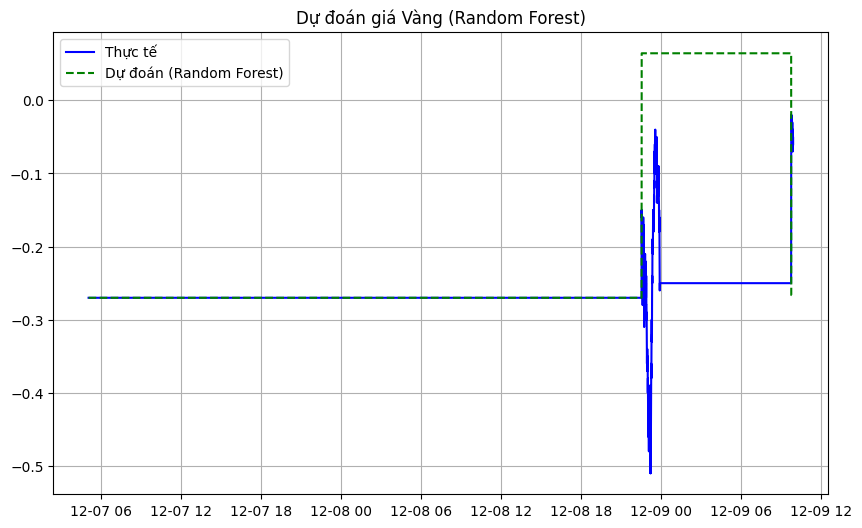

In [18]:
# 6. VẼ BIỂU ĐỒ DỰ ĐOÁN
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test.values, label='Thực tế', color='blue')
plt.plot(y_test.index, pred_rf, label='Dự đoán (Random Forest)', color='green', linestyle='--')
plt.title('Dự đoán giá Vàng (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# 7. MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ
importances = model_rf.feature_importances_

fi_df = pd.DataFrame({
    'Yeu_to': X.columns,
    'Do_quan_trong': importances
}).sort_values(by='Do_quan_trong', ascending=False)

print("\n=== MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ ===")
print(fi_df)


=== MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ ===
           Yeu_to  Do_quan_trong
0       Gold_lag1       0.974782
3      Wheat_lag1       0.025107
2     Silver_lag1       0.000090
4  USD index_lag1       0.000018
1      Brent_lag1       0.000003


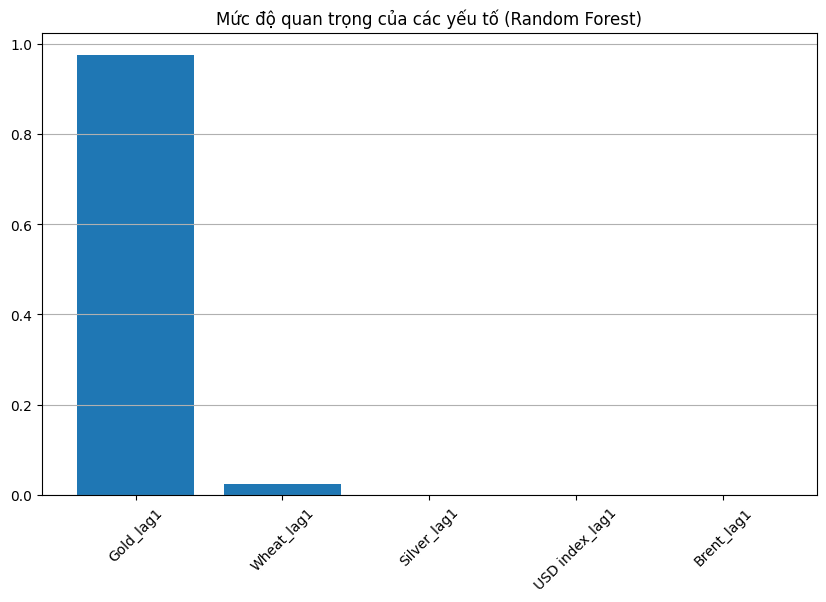

In [20]:
# 8. VẼ BIỂU ĐỒ MỨC ĐỘ ẢNH HƯỞNG CỦA CÁC YẾU TỐ
plt.figure(figsize=(10,6))
plt.bar(fi_df['Yeu_to'], fi_df['Do_quan_trong'])
plt.title('Mức độ quan trọng của các yếu tố (Random Forest)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()